In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.collections import LineCollection
from collections import Counter
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
from scipy.stats import ttest_1samp
from scipy.stats import gaussian_kde

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

In [ ]:
dataF = np.load('dataF.npy')
dataN = np.load('dataN.npy')
dataO = np.load('dataO.npy')
dataS = np.load('dataS.npy')
dataZ = np.load('dataZ.npy')

folders = [dataZ, dataO, dataN, dataF, dataS]
filenames = ['Z', 'O', 'N', 'F', 'S']

folders = [dataF, dataN, dataO, dataS, dataZ]
filenames = ['F', 'N', 'O', 'S', 'Z']
setnames = ['A', 'B', 'C', 'D', 'E']

# Colormap and normalization
cmap = plt.cm.viridis
norm = plt.Normalize(0.5, 1.5)

data = dataF[0]

time = np.linspace(0, 23.6, len(dataF[0]))

scales = 9
epochs = np.logspace(
    np.log10(4),
    np.log10(4096/4),
    scales)

x_extrapolate = np.linspace(4, 4096/4, 100)

print(epochs)

[   4.    8.   16.   32.   64.  128.  256.  512. 1024.]


In [58]:
def prepros(tseries):
    mean = np.mean(tseries)
    mean_centered = tseries - mean
    prepros = np.cumsum(mean_centered)
    return prepros

def linear(x, m, b):
    return m*x + b

def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

def sigmoid(x, L, x0, k, b):
    z = k * (x - x0)
    z = np.clip(z, -60, 60)  # prevent overflow
    return L / (1 + np.exp(-z)) + b

def fitting_sig(x, y, p0=None):
    # default starting guess
    if p0 is None:
        L0 = np.max(y) - np.min(y)
        x0_0 = np.median(x)
        k0 = 1.0
        b0 = np.min(y)
        p0 = [L0, x0_0, k0, b0]

    # residuals
    def residuals(params, x_obs, y_obs):
        return sigmoid(x_obs, *params) - y_obs

    result = least_squares(
        residuals,
        p0,
        args=(x, y),
        method="trf",
        max_nfev=20000
    )

    return result.x

def fitting_lin(segment_x, segment_y):
    popt, pcov = curve_fit(linear, segment_x, segment_y)
    m, b = popt
    return m, b

def RMS_i(f1,f2,n):
    rms_i = np.sqrt( (1/n) * np.sum((f1 - f2)**2) )
    return rms_i

def RMS(residuals):
    F_n = np.sqrt( np.mean (np.array(residuals)**2) )
    return F_n

def DFA(prepros):
    RMS_lin_list = []
    # RMS_sig_list = []

    for i in epochs:
        boundaries = np.arange(0,4097,i).astype(int)
        residuals_lin = np.array([])
        # residuals_sig = np.array([])

        # Epoch processing
        for j in range(len(boundaries)-1):
            segment_x = [k for k in range(int(boundaries[j]), int(boundaries[j+1]))]
            segment_y = prepros[boundaries[j]:boundaries[j+1]]

            # Fitting
            m, b = fitting_lin(segment_x, segment_y)
            # L, x0, k, b = fitting_sig(segment_x, segment_y)

            # RMS Computation 
            residuals_lin = np.concatenate(( residuals_lin , np.array(segment_y) - np.array(linear(np.array(segment_x), m, b)) ))
            # np.concatenate(( residuals_sig , np.array(segment_y) - np.array(sigmoid(np.array(segment_x), L, x0, k, b)) ))

        RMS_lin = RMS( residuals_lin )
        RMS_lin_list.append(RMS_lin)
    

    return RMS_lin_list #, RMS_sig_list

In [59]:
# WHITE NOISE
wn = np.random.normal(0, 1, 4097)
processed_wn = prepros(wn)
DFA_result_wn = DFA(processed_wn)

m_wn , b_wn = fitting_lin(np.log(epochs), np.log(DFA_result_wn))
Hurst_wn = m_wn

In [60]:
DFA_DataF = np.load('DFA_DataF.npy')
DFA_DataN = np.load('DFA_DataN.npy')
DFA_DataO = np.load('DFA_DataO.npy')
DFA_DataS = np.load('DFA_DataS.npy')
DFA_DataZ = np.load('DFA_DataZ.npy')

Hurst_DataF = np.load('Hurst_DataF.npy')
Hurst_DataN = np.load('Hurst_DataN.npy')
Hurst_DataO = np.load('Hurst_DataO.npy')
Hurst_DataS = np.load('Hurst_DataS.npy')
Hurst_DataZ = np.load('Hurst_DataZ.npy')

Data = [DFA_DataF, DFA_DataN, DFA_DataO, DFA_DataS, DFA_DataZ]
Hurst = [Hurst_DataF, Hurst_DataN, Hurst_DataO, Hurst_DataS, Hurst_DataZ]
Labels = ['F', 'N', 'O', 'S', 'Z']

500


C:\Users\rjnar\AppData\Local\Temp\ipykernel_17584\2761681984.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(Hurst, showmeans=True, meanline=True, labels=["A", "B", "C", "D", "E"])
C:\Users\rjnar\AppData\Local\Temp\ipykernel_17584\2761681984.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


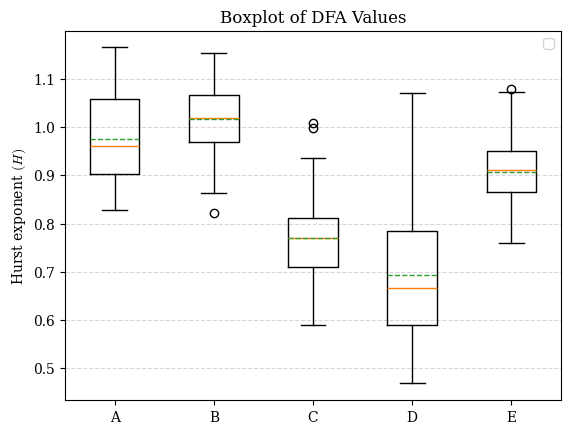

In [61]:
Hurst_all = np.concatenate((Hurst_DataF, Hurst_DataN, Hurst_DataO, Hurst_DataS, Hurst_DataZ))
print(len(Hurst_all))

plt.boxplot(Hurst, showmeans=True, meanline=True, labels=["A", "B", "C", "D", "E"])

plt.title("Boxplot of DFA Values")
plt.ylabel(f"Hurst exponent $(H)$")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.savefig('DFA Boxplot.png', dpi=200)
plt.legend()
plt.show()


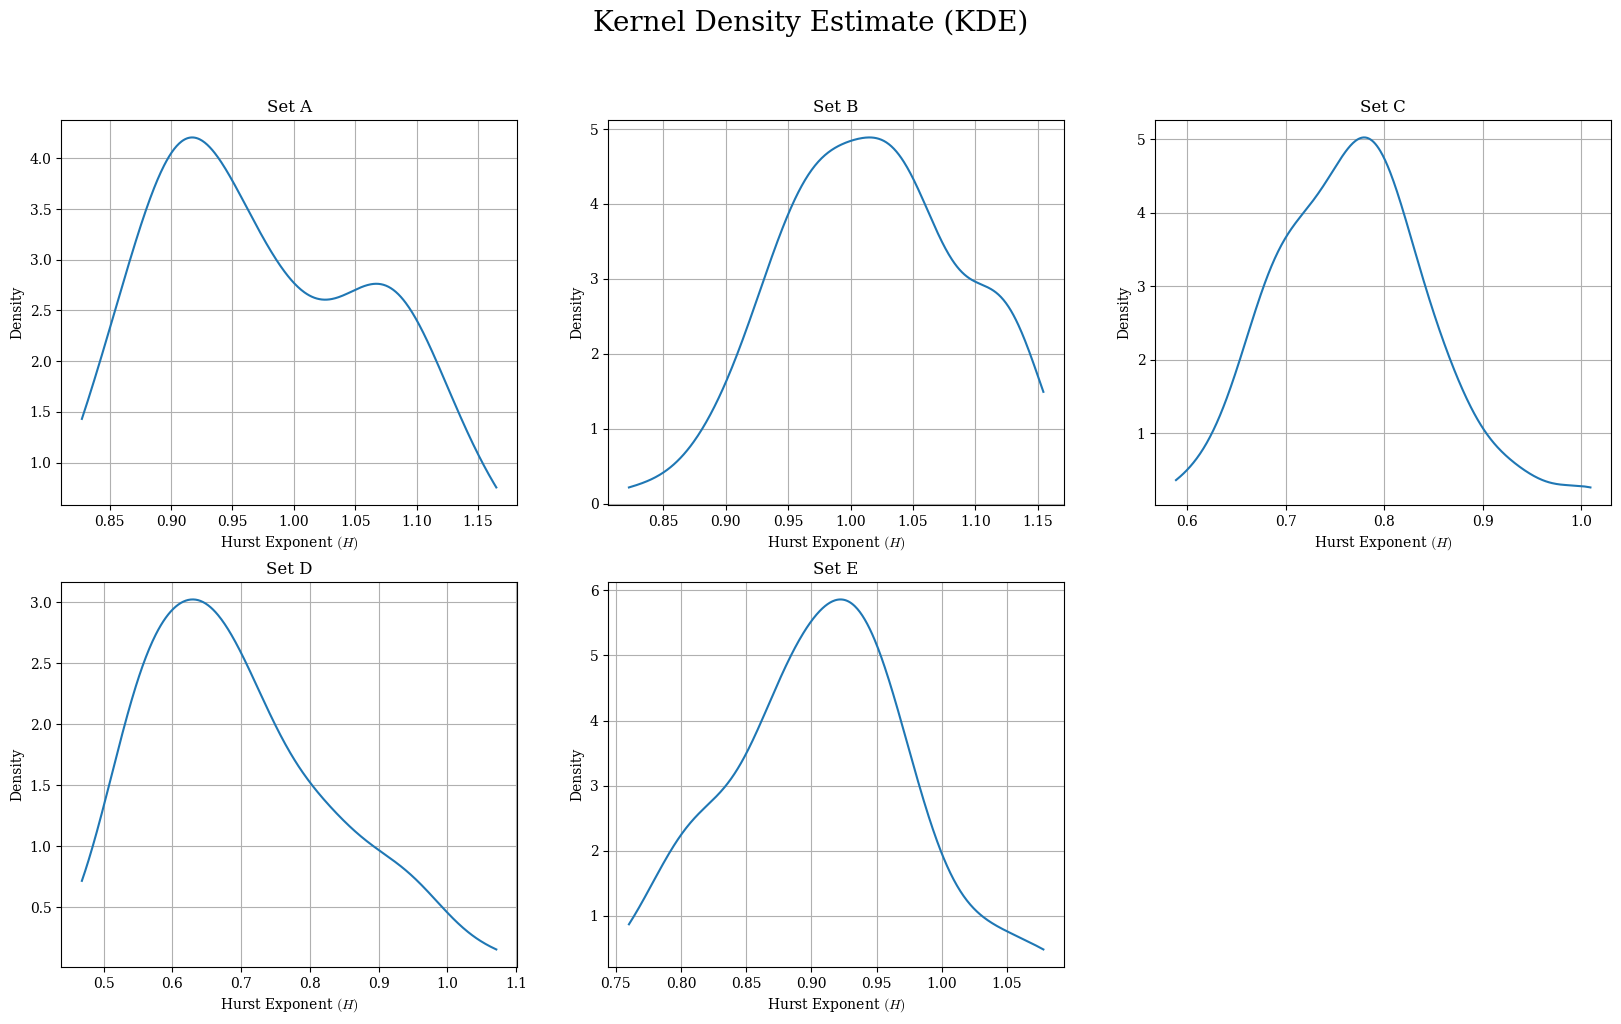

In [ ]:
fig, axs = plt.subplots(2,3, figsize=(20,11))
plt.suptitle(f'Kernel Density Estimate (KDE)', fontsize=20)
for i in range(2):
    for j in range(3):
        if i == 1 and j == 2:
            axs[i,j].axis('off')
        else:
            data2 = Hurst[i*3 + j]
            kde = gaussian_kde(np.array(data2))
            xs = np.linspace(min(data2), max(data2), 500)

            axs[i,j].plot(xs, kde(xs))
            axs[i,j].set_title(f"Set {setnames[i*3 + j]}")
            axs[i,j].grid(True)
            axs[i,j].set_xlabel(f'Hurst Exponent $(H)$')
            axs[i,j].set_ylabel(f'Density')
plt.savefig('KDE.png', dpi=200)

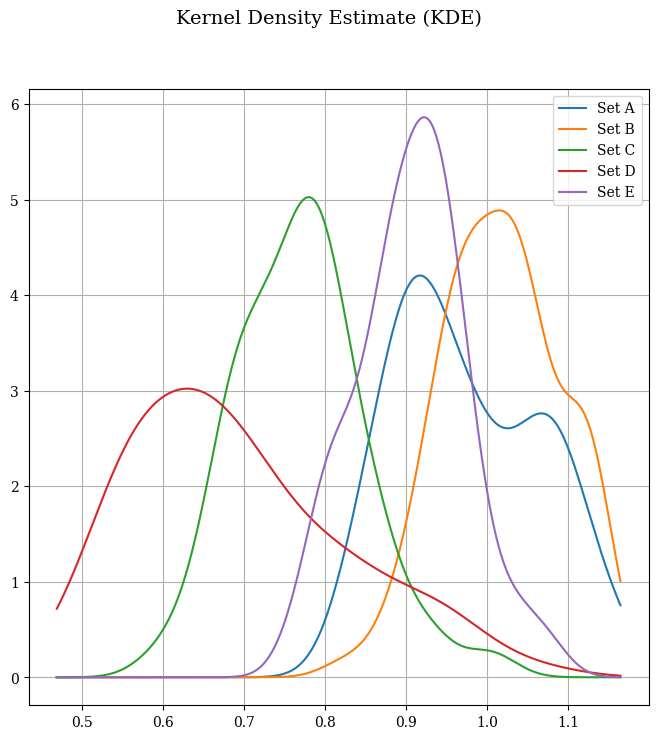

In [73]:
fig, axs = plt.subplots(figsize=(8, 8))
for i in range(5):
    data2 = Hurst[i]
    kde = gaussian_kde(np.array(data2))
    xs = np.linspace(min(Hurst_all), max(Hurst_all), 500)

    axs.plot(xs, kde(xs), label=(f'Set {setnames[i]}'))
axs.legend()
axs.grid(True)
plt.suptitle(f'Kernel Density Estimate (KDE)', fontsize=14)
plt.savefig('KDE_comparison.png', dpi=200)

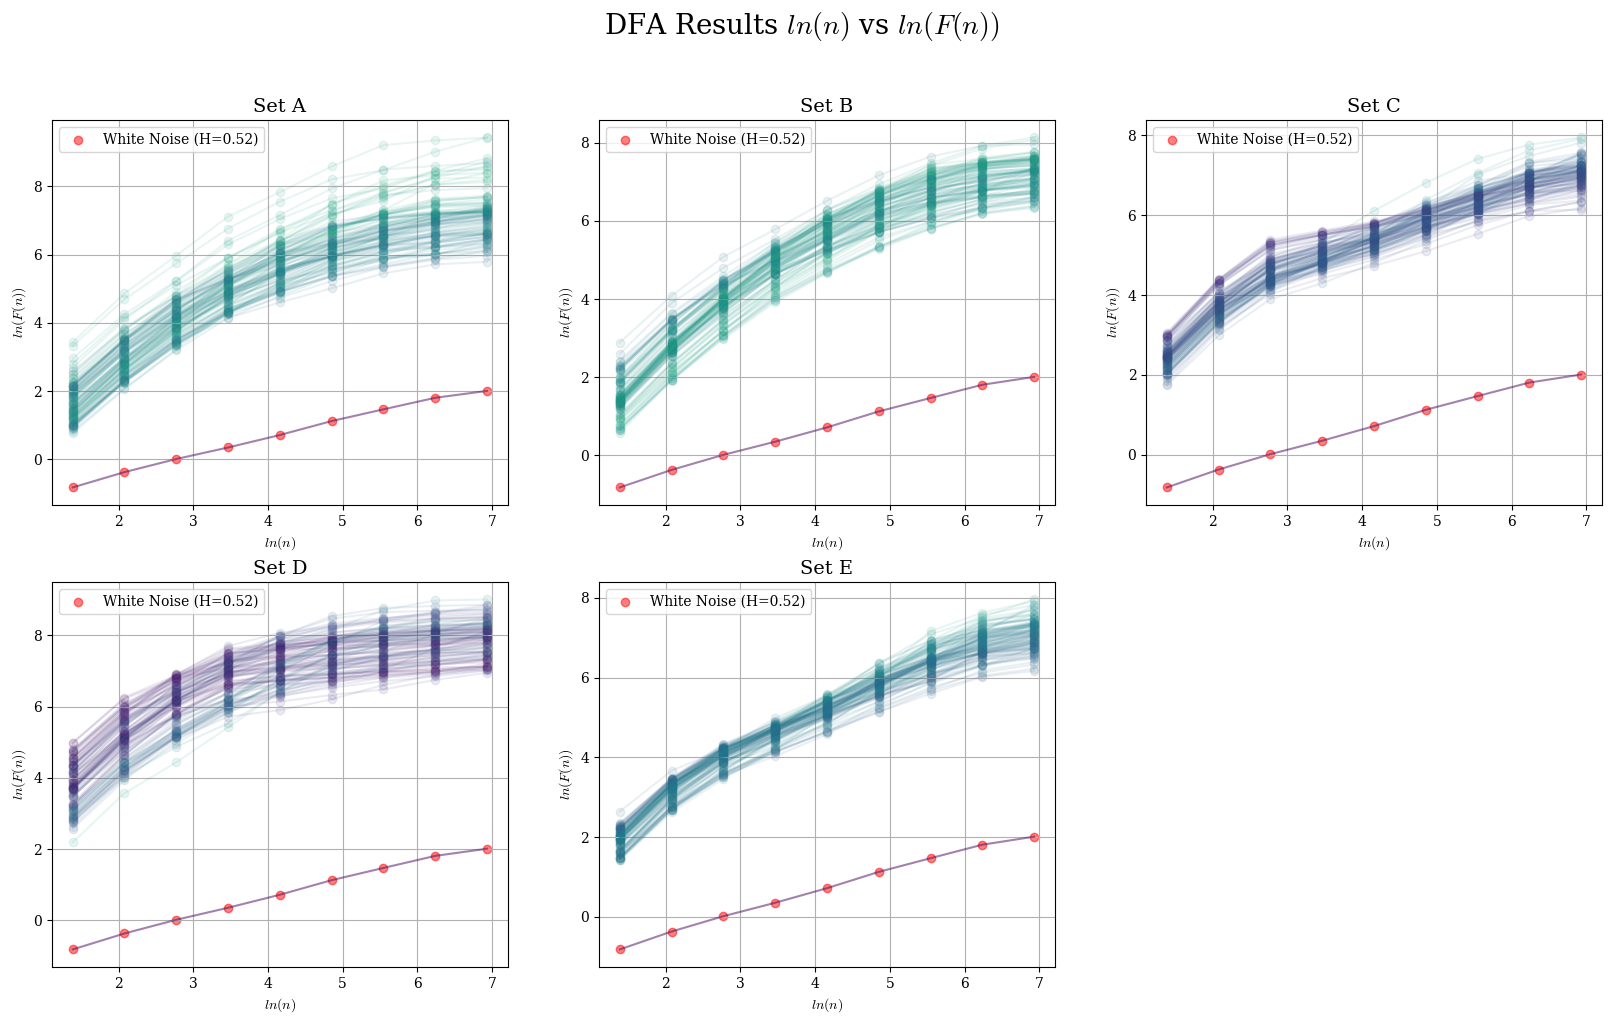

In [ ]:
fig, axs = plt.subplots(2,3, figsize=(20,11))
plt.suptitle(f'DFA Results $ln(n)$ vs $ln(F(n))$', fontsize=20)
for i in range(2):
    for j in range(3):
        if i == 1 and j == 2:
            axs[i,j].axis('off')
        else:
            for T in range(100):
                axs[i,j].plot(np.log(epochs), np.log(Data[i*3 + j][T]), color=cmap(norm(Hurst[i*3 + j][T])), alpha=0.1)
                axs[i,j].scatter(np.log(epochs), np.log(Data[i*3 + j][T]), color=cmap(norm(Hurst[i*3 + j][T])), alpha=0.1)
                axs[i,j].set_title(f'Set {setnames[i*3 + j]}', fontsize=14)
                axs[i,j].set_xlabel(f'$ln(n)$')
                axs[i,j].set_ylabel(f'$ln(F(n))$')

            axs[i,j].plot(np.log(epochs), np.log(DFA_result_wn), color=cmap(norm(Hurst_wn)), alpha=0.5)
            axs[i,j].scatter(np.log(epochs), np.log(DFA_result_wn), color='red', alpha=0.5, label=f'White Noise (H={Hurst_wn:.2f})')
            # axs[i,j].set_xscale('log')
            # axs[i,j].set_yscale('log')
            axs[i,j].legend()
            axs[i,j].grid(True)

plt.savefig(f'DFA Results.png', dpi=200)

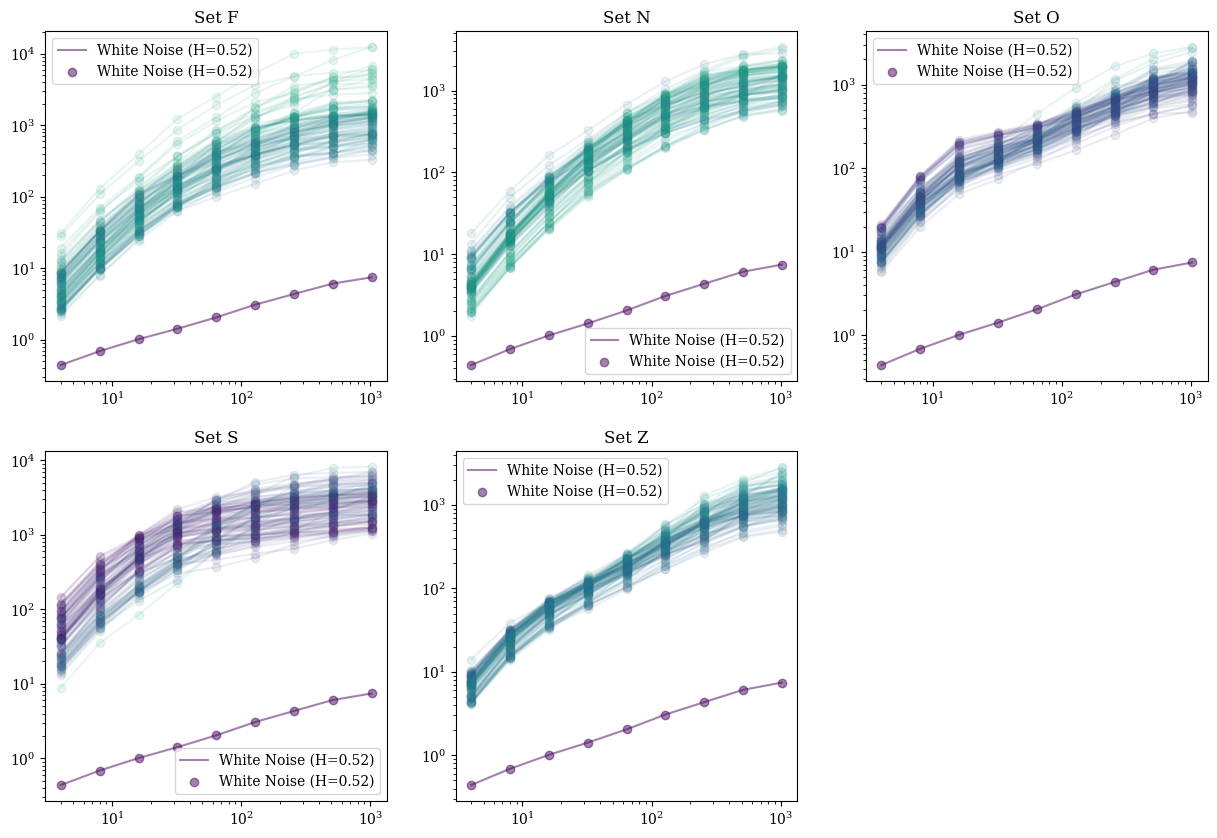

In [ ]:
fig, axs = plt.subplots(2,3,figsize=(15, 10))
for i in range(2):
    for j in range(3):
        if i == 1 and j == 2:
            axs[i,j].axis('off')
        else:
            for T in range(100):
                axs[i,j].plot(epochs, Data[i*3 + j][T], color=cmap(norm(Hurst[i*3 + j][T])), alpha=0.1)
                axs[i,j].scatter(epochs, Data[i*3 + j][T], color=cmap(norm(Hurst[i*3 + j][T])), alpha=0.1)
                axs[i,j].set_title(f'Set {filenames[i*3 + j]}')
                


            axs[i,j].plot(epochs, DFA_result_wn, color=cmap(norm(Hurst_wn)), alpha=0.5, label=f'White Noise (H={Hurst_wn:.2f})')
            axs[i,j].scatter(epochs, DFA_result_wn, color=cmap(norm(Hurst_wn)), alpha=0.5, label=f'White Noise (H={Hurst_wn:.2f})')
            axs[i,j].set_xscale('log')
            axs[i,j].set_yscale('log')
            axs[i,j].legend()